In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [65]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("/data/casestudy-2-creditcard.csv")

# Remove accidental spaces from column names
df.columns = df.columns.str.strip()

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

# Check target column
if "Class" not in df.columns:
    print("\nERROR: 'Class' column not found.")
    print("Available columns:", df.columns.tolist())
else:
    print("\nClass Distribution:")
    print(df["Class"].value_counts())

    print("\nClass Percentage:")
    print(df["Class"].value_counts(normalize=True) * 100)

Dataset Shape: (284807, 31)

Columns:

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Class Distribution:

0    284315

...

Name: Class, dtype: int64

Class Percentage:

0    99.827251

1     0.172749

Name: Class, dtype: float64

In [66]:
# ---------------------------------------------------
# 2. Separate features and target
# ---------------------------------------------------
X = df.drop("Class", axis=1)
y = df["Class"]

In [67]:
# ---------------------------------------------------
# 3. Split into train, validation and test
# ---------------------------------------------------
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    stratify=y_temp,
    random_state=42
)

print("\nTraining samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 170883

Validation samples: 56962

Testing samples: 56962

In [68]:
# ---------------------------------------------------
# 4. Apply SMOTE ONLY on training data
# ---------------------------------------------------
smote = SMOTE(
    random_state=42,
    sampling_strategy=1.0,
    k_neighbors=5
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())


After SMOTE:

0    170588

1    170588

Name: Class, dtype: int64

In [69]:
# ---------------------------------------------------
# 5. Train XGBoost
# ---------------------------------------------------
model = XGBClassifier(
    n_estimators=250,
    max_depth=5,
    learning_rate=0.08,
    subsample=0.85,
    colsample_bytree=0.85,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    n_jobs=4,
    random_state=42
)

model.fit(
    X_train_smote,
    y_train_smote,
    eval_set=[(X_val, y_val)],
    verbose=False
)

XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
 colsample_bylevel=1, colsample_bynode=1, colsample_bytree=0.85,
 early_stopping_rounds=None, enable_categorical=False,
 eval_metric='aucpr', gamma=0, gpu_id=-1, grow_policy='depthwise',
 importance_type=None, interaction_constraints='',
 learning_rate=0.08, max_bin=256, max_cat_to_onehot=4,
 max_delta_step=0, max_depth=5, max_leaves=0, min_child_weight=1,
 missing=nan, monotone_constraints='()', n_estimators=250,
 n_jobs=4, num_parallel_tree=1, predictor='auto', random_state=42,
 reg_alpha=0, reg_lambda=1, ...) In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook. On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org. XGBClassifier XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
 colsample_bylevel=1, colsample_bynode=1, colsample_bytree=0.85,
 early_stopping_rounds=None, enable_categorical=False,
 eval_metric='aucpr', gamma=0, gpu_id=-1, grow_policy='depthwise',
 importance_type=None, interaction_constraints='',
 learning_rate=0.08, max_bin=256, max_cat_to_onehot=4,
 max_delta_step=0, max_depth=5, max_leaves=0, min_child_weight=1,
 missing=nan, monotone_constraints='()', n_estimators=250,
 n_jobs=4, num_parallel_tree=1, predictor='auto', random_state=42,
 reg_alpha=0, reg_lambda=1, ...)

In [542]:
# ---------------------------------------------------
# 6. Predict probabilities
# ---------------------------------------------------
val_prob = model.predict_proba(X_val)[:, 1]
test_prob = model.predict_proba(X_test)[:, 1]

In [544]:
# ---------------------------------------------------
# 7. ROC-AUC and PR-AUC
# ---------------------------------------------------
print("\nValidation ROC-AUC:",
      roc_auc_score(y_val, val_prob))

print("Test ROC-AUC:",
      roc_auc_score(y_test, test_prob))

print("Validation PR-AUC:",
      average_precision_score(y_val, val_prob))

print("Test PR-AUC:",
      average_precision_score(y_test, test_prob))

Validation ROC-AUC: 0.9653192672730861

Test ROC-AUC: 0.9771958586473419

Validation PR-AUC: 0.808360765147463

Test PR-AUC: 0.8655220327202464

In [546]:
# ---------------------------------------------------
# 8. Find best decision threshold using validation set
#    Here we maximize F1-score
# ---------------------------------------------------
thresholds = np.linspace(0.001, 0.999, 999)

best_threshold = 0
best_f1 = 0

for threshold in thresholds:

    val_pred = (val_prob >= threshold).astype(int)

    score = f1_score(
        y_val,
        val_pred,
        zero_division=0
    )

    if score > best_f1:
        best_f1 = score
        best_threshold = threshold


print("\nBest Threshold:", round(best_threshold, 3))
print("Best Validation F1:", round(best_f1, 4))

In [548]:
# ---------------------------------------------------
# 9. Compare default threshold 0.5
#    with tuned threshold
# ---------------------------------------------------

# Default threshold
test_pred_05 = (test_prob >= 0.5).astype(int)

print("\n===== Threshold 0.5 =====")
print("Accuracy :",
      round(accuracy_score(y_test, test_pred_05), 4))
print("Precision:",
      round(precision_score(y_test, test_pred_05), 4))
print("Recall   :",
      round(recall_score(y_test, test_pred_05), 4))
print("F1 Score :",
      round(f1_score(y_test, test_pred_05), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, test_pred_05))


# Tuned threshold
test_pred_tuned = (test_prob >= best_threshold).astype(int)

print("\n===== Tuned Threshold =====")
print("Accuracy :",
      round(accuracy_score(y_test, test_pred_tuned), 4))
print("Precision:",
      round(precision_score(y_test, test_pred_tuned), 4))
print("Recall   :",
      round(recall_score(y_test, test_pred_tuned), 4))
print("F1 Score :",
      round(f1_score(y_test, test_pred_tuned), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, test_pred_tuned))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        test_pred_tuned,
        digits=4
    )
)


===== Threshold 0.5 =====

Accuracy : 0.9993

Precision: 0.7757

Recall   : 0.8469

F1 Score : 0.8098

...

           0     0.9997    0.9998    0.9998     56864

           1     0.8925    0.8469    0.8691        98

    accuracy                         0.9996     56962

   macro avg     0.9461    0.9234    0.9344     56962

weighted avg     0.9996    0.9996    0.9996     56962

In [550]:

# ---------------------------------------------------
# 10. Feature importance
# ---------------------------------------------------
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\n===== Feature Importance =====")
print(importance.head(15))



===== Feature Importance =====

V14    0.489295

V10    0.154521

V12    0.083208

V4     0.053110

...

V21    0.009744

V13    0.009597

V18    0.008647

V19    0.008026

dtype: float32

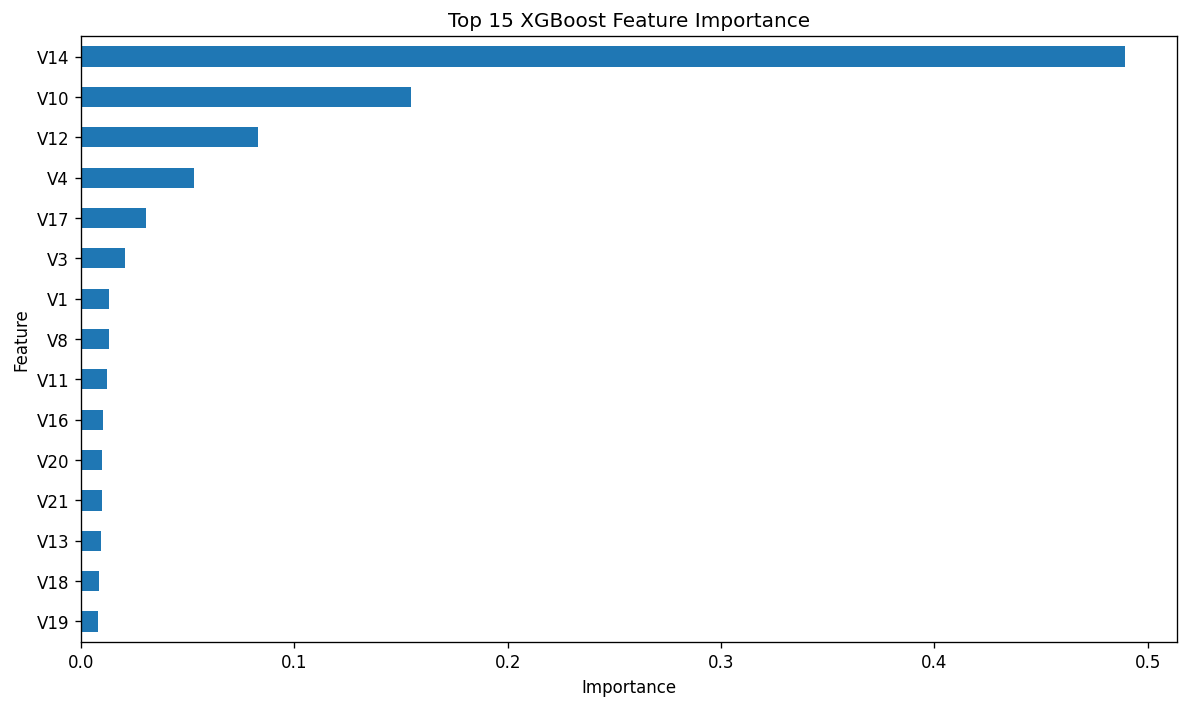

In [551]:
# ---------------------------------------------------
# 11. Plot top 15 features
# ---------------------------------------------------
top_features = importance.head(15).sort_values()

plt.figure(figsize=(10, 6))
top_features.plot(kind="barh")

plt.title("Top 15 XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()